In [1]:
import numpy as np
import matplotlib.pyplot as plt
import shtns
from tqdm import tqdm
plt.rcParams.update({'font.size': 12})
plt.rcParams['font.family'] = 'sans-serif'

In [2]:
# zlm_uphi = np.load('/data/seismo/joshin/pipeline-test/lct_data_processed/zlm_uphi_hmi_m_1h_all_2010_2023.npy')
# zlm_uthe = np.load('/data/seismo/joshin/pipeline-test/lct_data_processed/zlm_uthe_hmi_m_1h_all_2010_2023.npy')
# zlm_rvort = np.load('/data/seismo/joshin/pipeline-test/lct_data_processed/zlm_data/zlm_rvort_all_l35_m35_carr.npy')
# zlm_hdiv = np.load('/data/seismo/joshin/pipeline-test/lct_data_processed/zlm_data/zlm_hdiv_all_l35_m35_carr.npy')
# zlm_rvort_gran = np.load('/data/seismo/joshin/pipeline-test/lct_data_processed/zlm_data/zlm_rvort_all_l35_m35_carr_gran.npy')
# zlm_hdiv_gran = np.load('/data/seismo/joshin/pipeline-test/lct_data_processed/zlm_data/zlm_hdiv_all_l35_m35_carr_gran.npy')
zlm_uphi = np.load('/data/seismo/joshin/pipeline-test/lct_data_processed/zlm_data/zlm_uphi_all_l35_m35_carr_m720s_dt_1h.npy')
zlm_uthe = np.load('/data/seismo/joshin/pipeline-test/lct_data_processed/zlm_data/zlm_uthe_all_l35_m35_carr_m720s_dt_1h.npy')
zlm_rvort = np.load('/data/seismo/joshin/pipeline-test/lct_data_processed/zlm_data/zlm_rvort_all_l35_m35_carr_m720s_dt_1h.npy')
zlm_hdiv = np.load('/data/seismo/joshin/pipeline-test/lct_data_processed/zlm_data/zlm_hdiv_all_l35_m35_carr_m720s_dt_1h.npy')

In [3]:
zlm_uphi_array = np.asarray(zlm_uphi, dtype=np.complex128)
zlm_uthe_array = np.asarray(zlm_uthe, dtype=np.complex128)
zlm_hdiv_array = np.asarray(zlm_hdiv, dtype=np.complex128)
zlm_rvort_array = np.asarray(zlm_rvort, dtype=np.complex128)
# zlm_hdiv_gran_array = np.asarray(zlm_hdiv_gran, dtype=np.complex128)
# zlm_rvort_gran_array = np.asarray(zlm_rvort_gran, dtype=np.complex128)
# print(zlm_rvort_gran_array.shape)

In [4]:
print(zlm_rvort_array[0, :])

[ 2.00817781e-08+0.00000000e+00j -1.48067190e-08+0.00000000e+00j
  3.81218100e-08+0.00000000e+00j -5.05656692e-09+0.00000000e+00j
  1.19346492e-07+0.00000000e+00j -1.66692261e-07+0.00000000e+00j
 -5.53734199e-08+0.00000000e+00j -8.89160092e-08+0.00000000e+00j
  8.08323005e-08+0.00000000e+00j -2.00487865e-07+0.00000000e+00j
  3.93162557e-07+0.00000000e+00j  2.32834198e-08+0.00000000e+00j
  4.85625555e-08+0.00000000e+00j -2.11440959e-07+0.00000000e+00j
  1.06261020e-07+0.00000000e+00j  8.57533507e-08+0.00000000e+00j
  1.40446382e-07+0.00000000e+00j -1.40179734e-07+0.00000000e+00j
  2.55558882e-07+0.00000000e+00j -4.31215986e-07+0.00000000e+00j
  5.92698058e-07+0.00000000e+00j -2.71317056e-07+0.00000000e+00j
  8.02711009e-08+0.00000000e+00j -2.43427924e-07+0.00000000e+00j
  2.91585893e-07+0.00000000e+00j -2.49221049e-07+0.00000000e+00j
  4.76923849e-07+0.00000000e+00j -8.46493361e-07+0.00000000e+00j
  2.58325404e-07+0.00000000e+00j -5.70427295e-07+0.00000000e+00j
  1.00209659e-06+0.000000

In [5]:
lmax = 35
mmax = 35
sh = shtns.sht(lmax, mmax)
freqs = np.fft.fftfreq(zlm_uphi_array.shape[0], d=6*3600)
zlm_uphi_ft = np.fft.fft(zlm_uphi_array, axis=0)
zlm_uthe_ft = np.fft.fft(zlm_uthe_array, axis=0)
zlm_hdiv_ft = np.fft.fft(zlm_hdiv_array, axis=0)
zlm_rvort_ft = np.fft.fft(zlm_rvort_array, axis=0)
# zlm_hdiv_gran_ft = np.fft.fft(zlm_hdiv_gran_array, axis=0)
# zlm_rvort_gran_ft = np.fft.fft(zlm_rvort_gran_array, axis=0)

In [6]:
def rebin_2d_vertical(arr, bin_factor):
    assert arr.shape[0] % bin_factor == 0, "Number of rows must be divisible by the bin factor"
    return np.median(arr.reshape(arr.shape[0] // bin_factor, bin_factor, arr.shape[1]), axis=1)
def rebin_1d(arr, bin_factor):
    assert len(arr) % bin_factor == 0, "Array length must be divisible by the bin factor"
    return np.median(arr.reshape(len(arr) // bin_factor, bin_factor), axis=1)


In [7]:
from scipy.ndimage import gaussian_filter1d

def smooth_array_gaussian(arr, sigma=2):
    """
    Smooths a 2D array along the first axis using a Gaussian filter.

    Parameters:
        arr (ndarray): Input array of shape (18000, 34).
        sigma (float): Standard deviation of the Gaussian kernel.

    Returns:
        ndarray: Smoothed array.
    """
    return gaussian_filter1d(arr, sigma=sigma, axis=0)

import numpy as np
from scipy.ndimage import convolve1d

def smooth_array(arr, window_size=5, mode='nearest'):
    """
    Smooths a 2D array along the first axis using a moving average filter.

    Parameters:
        arr (ndarray): Input array of shape (18000, 34).
        window_size (int): Size of the moving average window (should be odd for symmetry).
        mode (str): Boundary mode for convolution (e.g., 'nearest', 'mirror', 'constant').

    Returns:
        ndarray: Smoothed array of the same shape as input.
    """
    kernel = np.ones(window_size) / window_size
    smoothed_arr = convolve1d(arr, kernel, axis=0, mode=mode)
    return smoothed_arr


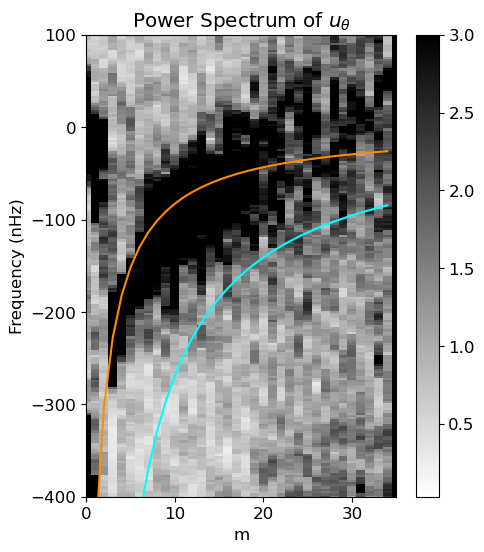

In [8]:
flist = []
for m in range(100):
    try:
        flist.append(zlm_uthe_ft[:, sh.idx(m, m)])
    except:
        break
flist = np.asarray(flist).T
flist_shifted = np.fft.fftshift(flist, axes=0)
freqs_shifted = -np.fft.fftshift(freqs)*1e9
power = np.abs(flist_shifted)**2
frqs_binned = rebin_1d(freqs_shifted, 1)
power_binned = rebin_2d_vertical(power, 1)
M_arr = np.arange(0,35)

freqs_for_median = (frqs_binned>-400) & (frqs_binned<-50)
power_median = np.nanmedian(power_binned[freqs_for_median, :], axis=0)
for m in range(35):
    power_binned[:, m] = power_binned[:, m]/power_median[m]

power_binned = smooth_array(power_binned, window_size=10)
fig, ax = plt.subplots(figsize = (5,6))
im = ax.pcolormesh(np.arange(flist_shifted.shape[1]), frqs_binned, power_binned, cmap = 'binary', vmax = 3)
ax.plot(M_arr, -2*456/(M_arr+1), 'darkorange',label = r'$\omega = -2\Omega/(m+1)$')
ax.plot(M_arr, -6.5*456/(M_arr+1), 'cyan',label = r'$\omega = -6.5\Omega/(m+1)$')
ax.set_ylim(-400, 100)
ax.set_xlim(0, 35)
ax.set_title(r'Power Spectrum of $u_{\theta}$')
ax.set_xlabel('m')
ax.set_ylabel('Frequency (nHz)')
fig.colorbar(im)

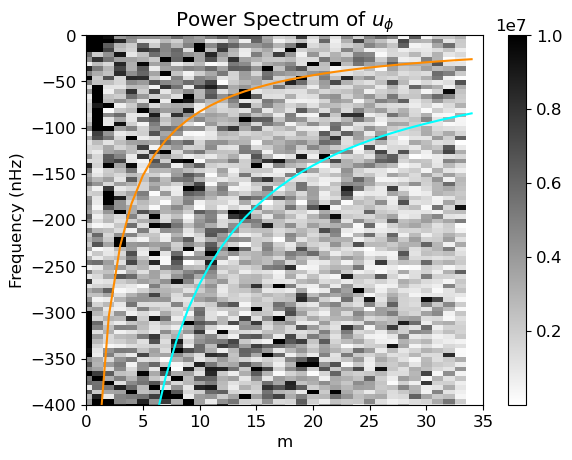

In [9]:
flist = []
for m in range(100):
    try:
        flist.append(zlm_uphi_ft[:, sh.idx(m+2, m)])
    except:
        break
flist = np.asarray(flist).T
flist_shifted = np.fft.fftshift(flist, axes=0)
freqs_shifted = -np.fft.fftshift(freqs)*1e9
power = np.abs(flist_shifted)**2
frqs_binned = rebin_1d(freqs_shifted, 2)
power_binned = rebin_2d_vertical(power, 2)
fig, ax = plt.subplots()
im = ax.pcolormesh(np.arange(flist_shifted.shape[1]), frqs_binned, power_binned, cmap = 'gray_r', vmax = 1e7)
ax.plot(M_arr, -2*456/(M_arr+1), 'darkorange',label = r'$\omega = -2\Omega/(m+1)$')
ax.plot(M_arr, -6.5*456/(M_arr+1), 'cyan',label = r'$\omega = -6.5\Omega/(m+1)$')
ax.set_ylim(-400, 0)
ax.set_xlim(0, 35)
ax.set_title(r'Power Spectrum of $u_{\phi}$')
ax.set_xlabel('m')
ax.set_ylabel('Frequency (nHz)')
fig.colorbar(im)

Text(0, 0.5, 'Frequency (nHz)')

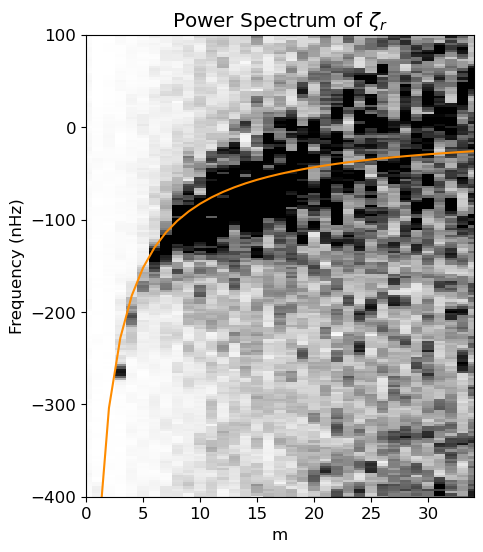

In [10]:
flist = []
for m in range(100):
    try:
        flist.append(zlm_rvort_ft[:, sh.idx(m, m)])
    except:
        break
flist = np.asarray(flist).T
flist_shifted = np.fft.fftshift(flist, axes=0)
freqs_shifted = -np.fft.fftshift(freqs)*1e9
power = np.abs(flist_shifted)**2
frqs_binned = rebin_1d(freqs_shifted, 1)
power_binned = rebin_2d_vertical(power, 1)
M_arr = np.arange(0,35)

freqs_for_median = (frqs_binned>-400) & (frqs_binned<100)
power_median = np.nanmedian(power_binned[freqs_for_median, :], axis=0)
for m in range(35):
    power_binned[:, m] = power_binned[:, m]#/power_median[m]

power_binned = smooth_array(power_binned, window_size=5)
fig, ax = plt.subplots(figsize = (5,6))
im = ax.pcolormesh(np.arange(flist_shifted.shape[1]), frqs_binned, power_binned, cmap = 'binary',vmax = 5e-9, rasterized = True)
ax.plot(M_arr, -2*456/(M_arr+1), 'darkorange',label = r'$\omega = -2\Omega/(m+1)$')
# ax.plot(M_arr, -6.5*456/(M_arr+1), 'cyan',label = r'$\omega = -6.5\Omega/(m+1)$')
ax.set_ylim(-400, 100)
ax.set_xlim(0, 34)
ax.set_title(r'Power Spectrum of $\zeta_r$')
ax.set_xlabel('m')
ax.set_ylabel('Frequency (nHz)')
# fig.savefig('zeta_r_power_spectrum.pdf', bbox_inches = 'tight')
# fig.colorbar(im)

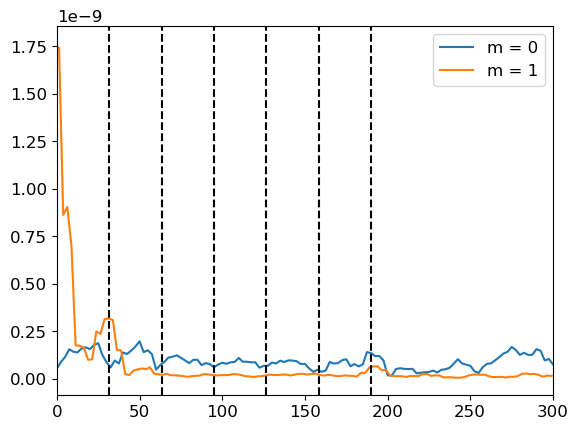

In [11]:
plt.figure()
plt.plot(frqs_binned, power_binned[:, 0], label = 'm = 0')
plt.plot(frqs_binned+424, power_binned[:, 1], label = 'm = 1')
plt.axvline(x = 31.7, color = 'k', linestyle = '--')
plt.axvline(x = 2*31.7, color = 'k', linestyle = '--')
plt.axvline(x = 3*31.7, color = 'k', linestyle = '--')
plt.axvline(x = 4*31.7, color = 'k', linestyle = '--')
plt.axvline(x = 5*31.7, color = 'k', linestyle = '--')
plt.axvline(x = 6*31.7, color = 'k', linestyle = '--')
plt.xlim(0, 300)
plt.legend()
# plt.ylim(0, 20)

41.52926015872039
103.94422819088062
133.72828614068553


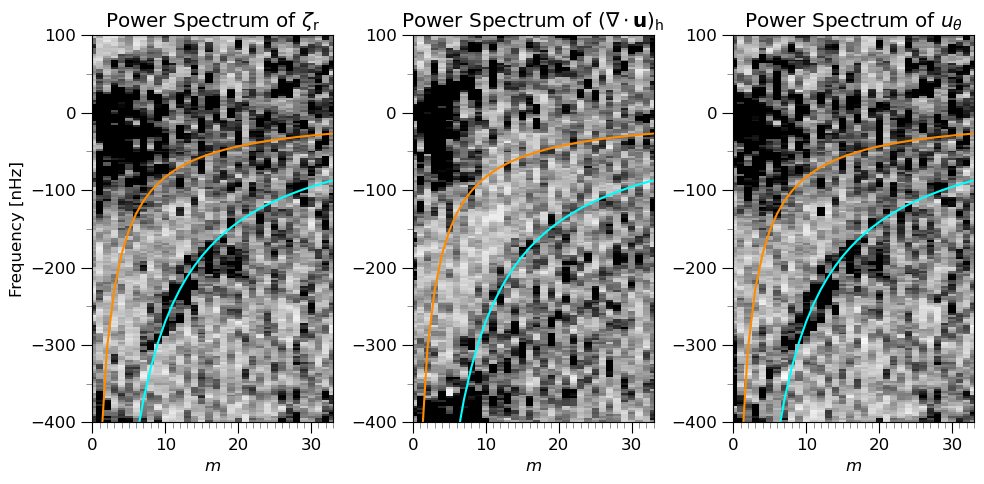

In [12]:
# Make plot with utheta and rvort together
flist_rvort = []
flist_uthe = []
flist_hdiv = []
for m in range(100):
    try:
        flist_rvort.append(zlm_rvort_ft[:, sh.idx(m+1, m)])
        flist_uthe.append(zlm_uthe_ft[:, sh.idx(m+1, m)])
        flist_hdiv.append(zlm_hdiv_ft[:, sh.idx(m, m)])
    except:
        break

flist_rvort = np.asarray(flist_rvort).T
flist_uthe = np.asarray(flist_uthe).T
flist_hdiv = np.asarray(flist_hdiv).T
flist_rvort_shifted = np.fft.fftshift(flist_rvort, axes=0)
flist_uthe_shifted = np.fft.fftshift(flist_uthe, axes=0)
flist_hdiv_shifted = np.fft.fftshift(flist_hdiv, axes=0)
power_rvort = np.abs(flist_rvort_shifted)**2
power_uthe = np.abs(flist_uthe_shifted)**2
power_hdiv = np.abs(flist_hdiv_shifted)**2
frqs_binned = rebin_1d(freqs_shifted, 1)
power_rvort_binned = rebin_2d_vertical(power_rvort, 1)
power_uthe_binned = rebin_2d_vertical(power_uthe, 1)
power_hdiv_binned = rebin_2d_vertical(power_hdiv, 1)
M_arr = np.arange(0,35)
freqs_for_median = (frqs_binned>-400) & (frqs_binned<-50)
power_median_uthe = np.nanmedian(power_uthe_binned[freqs_for_median, :], axis=0)
power_median_rvort = np.nanmedian(power_rvort_binned[freqs_for_median, :], axis=0)
power_median_hdiv = np.nanmedian(power_hdiv_binned[freqs_for_median, :], axis=0)
for m in range(34):
    power_uthe_binned[:, m] = power_uthe_binned[:, m]/power_median_uthe[m]
    power_rvort_binned[:, m] = power_rvort_binned[:, m]/power_median_rvort[m]
    power_hdiv_binned[:, m] = power_hdiv_binned[:, m]/power_median_hdiv[m]
power_uthe_binned = smooth_array(power_uthe_binned, window_size=5)
power_rvort_binned = smooth_array(power_rvort_binned, window_size=5)
power_hdiv_binned = smooth_array(power_hdiv_binned, window_size=5)

fig, ax = plt.subplots(1, 3, figsize = (10, 5))
im = ax[0].pcolormesh(np.arange(flist_rvort_shifted.shape[1]), frqs_binned, power_rvort_binned, cmap = 'binary', vmax = 3, rasterized = True)
# im = ax[0].pcolormesh(np.arange(flist_rvort_shifted.shape[1]), frqs_binned, power_rvort_binned, cmap = 'binary', rasterized = True, vmax = 5e-9)
ax[0].plot(M_arr, -2*456/(M_arr+1), 'darkorange',label = r'$\omega = -2\Omega/(m+1)$')
ax[0].plot(M_arr, -6.5*456/(M_arr+1), 'cyan',label = r'$\omega = -6.5\Omega/(m+1)$')
ax[0].set_ylim(-400, 100)
ax[0].set_xlim(0, 33)
ax[0].set_xticks(np.arange(0, 34, 1), minor = True)
ax[0].set_yticks(np.arange(-400, 101, 100), minor = False)
ax[0].set_yticks(np.arange(-400, 101, 50), minor = True)
ax[0].tick_params(which='minor', length=4, color='gray')
ax[0].tick_params(which='major', length=8, color='black')
ax[0].set_title(r'Power Spectrum of $\zeta_\mathrm{r}$')
ax[0].set_xlabel(r'$m$')
ax[0].set_ylabel('Frequency [nHz]')
im = ax[2].pcolormesh(np.arange(flist_uthe_shifted.shape[1]), frqs_binned, power_uthe_binned, cmap = 'binary', vmax = 3, rasterized = True)
# im = ax[2].pcolormesh(np.arange(flist_uthe_shifted.shape[1]), frqs_binned, power_uthe_binned, cmap = 'binary', rasterized = True, vmax = 1e7)
ax[2].plot(M_arr, -2*456/(M_arr+1), 'darkorange',label = r'$\omega = -2\Omega/(m+1)$')
ax[2].plot(M_arr, -6.5*456/(M_arr+1), 'cyan',label = r'$\omega = -6.5\Omega/(m+1)$')
ax[2].set_ylim(-400, 100)
ax[2].set_xlim(0, 33)
ax[2].set_xticks(np.arange(0, 34, 1), minor = True)
ax[2].set_yticks(np.arange(-400, 101, 100), minor = False)
ax[2].set_yticks(np.arange(-400, 101, 50), minor = True)
ax[2].tick_params(which='minor', length=4, color='gray')
ax[2].tick_params(which='major', length=8, color='black')
ax[2].set_title(r'Power Spectrum of $u_{\theta}$')
ax[2].set_xlabel(r'$m$')
im = ax[1].pcolormesh(np.arange(flist_uthe_shifted.shape[1]), frqs_binned, power_hdiv_binned, cmap = 'binary', vmax = 3, rasterized = True)
# im = ax[1].pcolormesh(np.arange(flist_uthe_shifted.shape[1]), frqs_binned, power_hdiv_binned, cmap = 'binary', rasterized = True, vmax = 5e-9)
ax[1].plot(M_arr, -2*456/(M_arr+1), 'darkorange',label = r'$\omega = -2\Omega/(m+1)$')
ax[1].plot(M_arr, -6.5*456/(M_arr+1), 'cyan',label = r'$\omega = -6.5\Omega/(m+1)$')
ax[1].set_ylim(-400, 100)
ax[1].set_xlim(0, 33)
ax[1].set_xticks(np.arange(0, 34, 1), minor = True)
ax[1].set_yticks(np.arange(-400, 101, 100), minor = False)
ax[1].set_yticks(np.arange(-400, 101, 50), minor = True)
ax[1].tick_params(which='minor', length=4, color='gray')
ax[1].tick_params(which='major', length=8, color='black')
ax[1].set_title(r'Power Spectrum of $(\nabla \cdot \mathbf{u})_{\mathrm{h}}$')
ax[1].set_xlabel(r'$m$')
fig.tight_layout()
# fig.savefig('hfr_ps_rvort_uthe_hdiv.pdf', bbox_inches = 'tight')
print(power_rvort_binned[:, 3].max())
print(power_uthe_binned[:, 3].max())
print(power_hdiv_binned[:, 3].max())



(-250.0, -200.0)

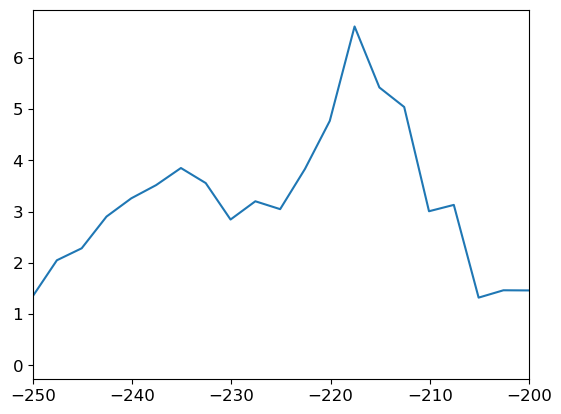

In [13]:
plt.plot(freqs_shifted, power_uthe_binned[:, 13])
plt.xlim(-250, -200)

In [23]:
df = frqs_binned[1] - frqs_binned[0]
print(df*5)

-12.5044015493404


In [13]:
df = freqs_shifted[1] - freqs_shifted[0]
print(df)

-2.50088030986808


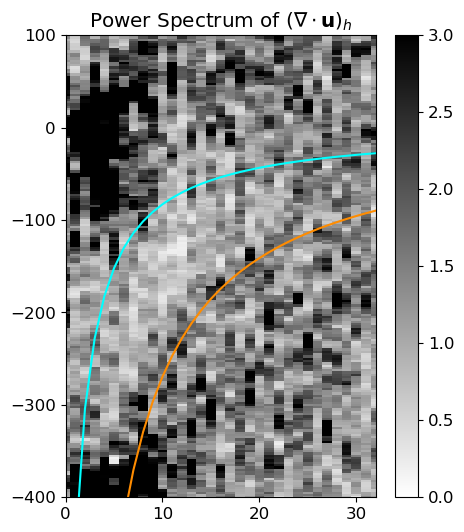

In [13]:
flist = []
for m in range(100):
    try:
        flist.append(zlm_hdiv_ft[:, sh.idx(m, m)])
    except:
        break
flist = np.asarray(flist).T
flist_shifted = np.fft.fftshift(flist, axes=0)
freqs_shifted = -np.fft.fftshift(freqs)*1e9
power = np.abs(flist_shifted)**2
frqs_binned = rebin_1d(freqs_shifted, 1)
power_binned = rebin_2d_vertical(power, 1)
freqs_for_median = (frqs_binned>-400) & (frqs_binned<-100)
for m in range(34):
    power_binned[:, m] = power_binned[:, m] / np.nanmedian(power_binned[freqs_for_median, m])
power_binned = smooth_array(power_binned, window_size=6)
fig, ax = plt.subplots(figsize = (5,6))
im = ax.pcolormesh(np.arange(flist_shifted.shape[1]), frqs_binned, power_binned, cmap = 'gray_r', vmax = 3)
ax.plot(M_arr, -2*456/(M_arr+1), 'cyan',label = r'$\omega = -2\Omega/(m+1)$')
ax.plot(M_arr, -6.5*456/(M_arr+1), 'darkorange',label = r'$\omega = -6.5\Omega/(m+1)$')
ax.set_ylim(-400, 100)
ax.set_xlim(0, 32)
ax.set_title(r'Power Spectrum of $(\nabla \cdot \mathbf{u})_h$')
fig.colorbar(im)

In [15]:
flist_mag = []
flist_gran = []
for m in range(100):
    try:
        flist_gran.append(zlm_rvort_gran_ft[:, sh.idx(m, m)])
        flist_mag.append(zlm_rvort_ft[:, sh.idx(m, m)])
    except:
        break
flist_mag = np.asarray(flist_mag).T
flist_gran = np.asarray(flist_gran).T
flist_mag_shifted = np.fft.fftshift(flist_mag, axes=0)
flist_gran_shifted = np.fft.fftshift(flist_gran, axes=0)
freqs_shifted = -np.fft.fftshift(freqs)*1e9
power_mag = np.abs(flist_mag_shifted)**2
power_gran = np.abs(flist_gran_shifted)**2
frqs_binned = rebin_1d(freqs_shifted, 1)
power_mag_binned = rebin_2d_vertical(power_mag, 2)
power_gran_binned = rebin_2d_vertical(power_gran, 2)
# power_binned = rebin_2d_vertical(power, 1)
M_arr = np.arange(0,35)


freqs_for_median = (frqs_binned>-400) & (frqs_binned<-50)
power_mag_median = np.nanmedian(power_mag_binned[freqs_for_median, :], axis=0)
power_gran_median = np.nanmedian(power_gran_binned[freqs_for_median, :], axis=0)
for m in range(35):
    power_mag_binned[:, m] = power_mag_binned[:, m]#/power_mag_median[m]
    power_gran_binned[:, m] = power_gran_binned[:, m]#/power_gran_median[m]

# power_binned = smooth_array(power_binned, window_size=5)
power_mag_binned = smooth_array(power_mag_binned, window_size=5)
power_gran_binned = smooth_array(power_gran_binned, window_size=5)




fig, ax = plt.subplots(1, 2, figsize = (8,6))
im = ax[0].pcolormesh(np.arange(flist_mag_shifted.shape[1]), frqs_binned, power_mag_binned, cmap = 'binary',vmax = 7e-9, rasterized = True)
ax[0].plot(M_arr, -2*456/(M_arr+1), 'darkorange',label = r'$\omega = -2\Omega/(m+1)$')
# ax[0].plot(M_arr, -6.5*456/(M_arr+1), 'cyan',label = r'$\omega = -6.5\Omega/(m+1)$')
ax[0].set_ylim(-400, 100)
ax[0].set_xlim(0, 34)
ax[0].set_title(r'Power Spectrum of $\zeta_r$ (LCTMag)')
ax[0].set_xlabel(r'$m$')
ax[0].set_ylabel('Frequency [nHz]')
ax[0].set_ylim(-400, 100)
ax[0].set_xlim(0, 33)
ax[0].set_xticks(np.arange(0, 34, 1), minor = True)
ax[0].set_yticks(np.arange(-400, 101, 100), minor = False)
ax[0].set_yticks(np.arange(-400, 101, 50), minor = True)
ax[0].tick_params(which='minor', length=4, color='gray')
ax[0].tick_params(which='major', length=8, color='black')
im = ax[1].pcolormesh(np.arange(flist_gran_shifted.shape[1]), frqs_binned, power_gran_binned, cmap = 'binary', vmax = 7e-9, rasterized = True)
ax[1].plot(M_arr, -2*456/(M_arr+1), 'darkorange',label = r'$\omega = -2\Omega/(m+1)$')
# ax[1].plot(M_arr, -6.5*456/(M_arr+1), 'cyan',label = r'$\omega = -6.5\Omega/(m+1)$')
ax[1].set_ylim(-400, 100)
ax[1].set_xlim(0, 34)
ax[1].set_title(r'Power Spectrum of $\zeta_r$ (LCTGran)')
ax[1].set_xlabel(r'$m$')
ax[1].set_ylim(-400, 100)
ax[1].set_xlim(0, 33)
ax[1].set_xticks(np.arange(0, 34, 1), minor = True)
ax[1].set_yticks(np.arange(-400, 101, 100), minor = False)
ax[1].set_yticks(np.arange(-400, 101, 50), minor = True)
ax[1].tick_params(which='minor', length=4, color='gray')
ax[1].tick_params(which='major', length=8, color='black')
fig.tight_layout()
# fig.savefig('zeta_r_power_spectrum_mag_gran.pdf', bbox_inches = 'tight')
# fig.colorbar(im)

IndexError: tuple index out of range